Bibliotecas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

Definições do Dataset

In [8]:
df_original = pd.read_csv("../Dados/RESULTADOS_2024.csv", encoding="latin-1", sep=";")
pd.set_option('display.max_columns', None)
df = df_original.copy() # cópia do Dataset original para não altera-lo

Drop das colunas que não serão usadas para as analises, pois são dados que nao agregam em nada

In [9]:
df = df.drop(columns=["CO_ESCOLA", "CO_MUNICIPIO_ESC", "NO_MUNICIPIO_ESC", "CO_UF_ESC", "SG_UF_ESC", "TP_DEPENDENCIA_ADM_ESC", "TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC", "CO_MUNICIPIO_PROVA", "CO_UF_PROVA",  "TX_GABARITO_CH", "TX_GABARITO_LC", "TX_GABARITO_MT", "TX_RESPOSTAS_MT", "TX_GABARITO_CN", "TX_RESPOSTAS_CN", "TX_RESPOSTAS_CH", "TX_RESPOSTAS_LC"])

In [10]:
df.head()

,NU_SEQUENCIAL,NU_ANO,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,Aratuba,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,1,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,Tijucas,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,0,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,Rolândia,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,1,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,Osasco,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,0,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,São Mateus do Maranhão,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Renomeação das colunas para melhor entendimento

In [11]:
df.rename(columns={
    'NU_SEQUENCIAL': 'Id',
    'NU_ANO': 'Ano Realizado',
    'NO_MUNICIPIO_PROVA': 'Municipio',
    'SG_UF_PROVA': 'Sigla_Estado',
    'TP_PRESENCA_CN': 'Presenca_CN',
    'TP_PRESENCA_CH': 'Presenca_CH',
    'TP_PRESENCA_LC': 'Presenca_LC',
    'TP_PRESENCA_MT': 'Presenca_MT',
    'CO_PROVA_CN': 'Prova_CN',
    'CO_PROVA_CH': 'Prova_CH',
    'CO_PROVA_LC': 'Prova_LC',
    'CO_PROVA_MT': 'Prova_MT',
    'NU_NOTA_CN': 'Nota_CN',
    'NU_NOTA_CH': 'Nota_CH',
    'NU_NOTA_LC': 'Nota_LC',
    'NU_NOTA_MT': 'Nota_MT',
    'TP_LINGUA': 'Lingua_Estrangeira',
    'TP_STATUS_REDACAO': 'Status_Redacao',
    'NU_NOTA_COMP1': 'Nota_Comp1',
    'NU_NOTA_COMP2': 'Nota_Comp2',
    'NU_NOTA_COMP3': 'Nota_Comp3',
    'NU_NOTA_COMP4': 'Nota_Comp4',
    'NU_NOTA_COMP5': 'Nota_Comp5',
    'NU_NOTA_REDACAO': 'Nota_Redacao',
}, inplace=True)

Troca do tipo de variavel para melhor entendimento

In [12]:
df = df.astype({
    "Prova_CN": object,
    "Prova_CH":	object,
    "Prova_LC":	object,
    "Prova_MT": object,
    "Lingua_Estrangeira": object
})

Troca dos codigos dos tipos de prova para os nomes dos mesmo

*USADO IA PARA FAZER ISSO*

In [13]:
cores_cn = {
    1419: 'Azul',
    1420: 'Amarela',
    1421: 'Verde',
    1422: 'Cinza',
    1423: 'Verde - Ampliada',
    1424: 'Verde - Superampliada',
    1426: 'Laranja - Adaptada Ledor',
    1427: 'Roxa - Videoprova - Libras',
    1428: 'Roxa - Videoprova - Libras - Ampliada',
    1373: 'Azul (Reaplicação)',
    1374: 'Amarela (Reaplicação)',
    1375: 'Cinza (Reaplicação)',
    1376: 'Verde (Reaplicação)',
    1377: 'Verde - Ampliada (Reaplicação)',
    1378: 'Verde - Superampliada (Reaplicação)',
    1380: 'Laranja - Adaptada Ledor (Reaplicação)',
}
cores_ch = {
    1383: 'Azul',
    1384: 'Amarela',
    1385: 'Branca',
    1386: 'Verde',
    1387: 'Verde - Ampliada',
    1388: 'Verde - Superampliada',
    1390: 'Laranja - Adaptada Ledor',
    1391: 'Roxa - Videoprova - Libras',
    1392: 'Roxa - Videoprova - Libras - Ampliada',
    1393: 'Roxa - Videoprova - Libras - Superampliada',
    1343: 'Azul (Reaplicação)',
    1344: 'Amarela (Reaplicação)',
    1345: 'Branca (Reaplicação)',
    1346: 'Verde (Reaplicação)',
    1347: 'Verde - Ampliada (Reaplicação)',
    1348: 'Verde - Superampliada (Reaplicação)',
    1350: 'Laranja - Adaptada Ledor (Reaplicação)',
}
cores_lc = {
    1395: 'Azul',
    1396: 'Amarela',
    1397: 'Verde',
    1398: 'Branca',
    1399: 'Verde - Ampliada',
    1400: 'Verde - Superampliada',
    1402: 'Laranja - Adaptada Ledor',
    1403: 'Roxa - Videoprova - Libras',
    1404: 'Roxa - Videoprova - Libras - Ampliada',
    405:  'Roxa - Videoprova - Libras - Superampliada',  # código 405 conforme informado
    1353: 'Azul (Reaplicação)',
    1354: 'Amarela (Reaplicação)',
    1355: 'Verde (Reaplicação)',
    1356: 'Branca (Reaplicação)',
    1357: 'Verde - Ampliada (Reaplicação)',
    1358: 'Verde - Superampliada (Reaplicação)',
    1360: 'Laranja - Adaptada Ledor (Reaplicação)',
}
cores_mt = {
    1407: 'Azul',
    1408: 'Amarela',
    1409: 'Verde',
    1410: 'Cinza',
    1411: 'Verde - Ampliada',
    1412: 'Verde - Superampliada',
    1414: 'Laranja - Adaptada Ledor',
    1415: 'Roxa - Videoprova - Libras',
    1416: 'Roxa - Videoprova - Libras - Ampliada',
    1363: 'Azul (Reaplicação)',
    1364: 'Amarela (Reaplicação)',
    1365: 'Verde (Reaplicação)',
    1366: 'Cinza (Reaplicação)',
    1367: 'Verde - Ampliada (Reaplicação)',
    1368: 'Verde - Superampliada (Reaplicação)',
    1370: 'Laranja - Adaptada Ledor (Reaplicação)',
}

In [14]:
df['Prova_CN'] = df['Prova_CN'].map(cores_cn)
df['Prova_CH'] = df['Prova_CH'].map(cores_ch)
df['Prova_LC'] = df['Prova_LC'].map(cores_lc)
df['Prova_MT'] = df['Prova_MT'].map(cores_mt)

Troca dos codigos da linguagem escolhida

In [15]:
lingua = {
    0: "Ingles",
    1: "Espanhol"
}
df["Lingua_Estrangeira"] = df["Lingua_Estrangeira"].map(lingua)

In [16]:
df.head()

,Id,Ano Realizado,Municipio,Sigla_Estado,Presenca_CN,Presenca_CH,Presenca_LC,Presenca_MT,Prova_CN,Prova_CH,Prova_LC,Prova_MT,Nota_CN,Nota_CH,Nota_LC,Nota_MT,Lingua_Estrangeira,Status_Redacao,Nota_Comp1,Nota_Comp2,Nota_Comp3,Nota_Comp4,Nota_Comp5,Nota_Redacao
0,206403,2024,Aratuba,CE,1,1,1,1,Amarela,Azul,Azul,Amarela,436.8,377.8,423.4,427.1,Espanhol,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,Tijucas,SC,1,1,1,1,Cinza,Amarela,Amarela,Cinza,521.9,601.9,605.5,689.2,Ingles,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,Rolândia,PR,1,1,1,1,Azul,Branca,Branca,Azul,363.0,548.4,557.2,456.4,Espanhol,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,Osasco,SP,1,1,1,1,Verde,Verde,Verde,Verde,550.7,553.8,605.9,629.1,Ingles,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,São Mateus do Maranhão,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Espanhol,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Inspecionar quantidade de valores nulos e onde se encontram

In [17]:
df.isnull().sum()

Id                          0
Ano Realizado               0
Municipio                   0
Sigla_Estado                0
Presenca_CN                 0
Presenca_CH                 0
Presenca_LC                 0
Presenca_MT                 0
Prova_CN              1327963
Prova_CH              1164989
Prova_LC              1164989
Prova_MT              1327963
Nota_CN               1327963
Nota_CH               1164989
Nota_LC               1164989
Nota_MT               1327963
Lingua_Estrangeira          0
Status_Redacao        1164989
Nota_Comp1            1164989
Nota_Comp2            1164989
Nota_Comp3            1164989
Nota_Comp4            1164989
Nota_Comp5            1164989
Nota_Redacao          1164989
dtype: int64

Filtros apenas dos participantes presentes nos dois dias e não desclassificados

In [18]:
df = df.query(
    "Presenca_CH == 1 and Presenca_LC == 1 and "
    "Presenca_CN == 1 and Presenca_MT == 1"
)

Check se o filtro funcionou

In [19]:
df.isnull().sum()

Id                    0
Ano Realizado         0
Municipio             0
Sigla_Estado          0
Presenca_CN           0
Presenca_CH           0
Presenca_LC           0
Presenca_MT           0
Prova_CN              0
Prova_CH              0
Prova_LC              0
Prova_MT              0
Nota_CN               0
Nota_CH               0
Nota_LC               0
Nota_MT               0
Lingua_Estrangeira    0
Status_Redacao        0
Nota_Comp1            0
Nota_Comp2            0
Nota_Comp3            0
Nota_Comp4            0
Nota_Comp5            0
Nota_Redacao          0
dtype: int64

Colunas Quantitativas e Qualitativas

In [20]:
colunas_quantitativas =  df.select_dtypes(include=['number']).columns.to_list()
print("Colunas Quantitativas: ")
print(colunas_quantitativas)

Colunas Quantitativas: 
['Id', 'Ano Realizado', 'Presenca_CN', 'Presenca_CH', 'Presenca_LC', 'Presenca_MT', 'Nota_CN', 'Nota_CH', 'Nota_LC', 'Nota_MT', 'Status_Redacao', 'Nota_Comp1', 'Nota_Comp2', 'Nota_Comp3', 'Nota_Comp4', 'Nota_Comp5', 'Nota_Redacao']


In [21]:
colunas_qualitativas =  df.select_dtypes(include=['object']).columns.to_list() # mudei o include de 'str' para 'object' por que deu erro e pediu para usar 'object'
print("Colunas Qualitativas: ")
print(colunas_qualitativas)

Colunas Qualitativas: 
['Municipio', 'Sigla_Estado', 'Prova_CN', 'Prova_CH', 'Prova_LC', 'Prova_MT', 'Lingua_Estrangeira']


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2990093 entries, 0 to 4332943
Data columns (total 24 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Id                  int64  
 1   Ano Realizado       int64  
 2   Municipio           object 
 3   Sigla_Estado        object 
 4   Presenca_CN         int64  
 5   Presenca_CH         int64  
 6   Presenca_LC         int64  
 7   Presenca_MT         int64  
 8   Prova_CN            object 
 9   Prova_CH            object 
 10  Prova_LC            object 
 11  Prova_MT            object 
 12  Nota_CN             float64
 13  Nota_CH             float64
 14  Nota_LC             float64
 15  Nota_MT             float64
 16  Lingua_Estrangeira  object 
 17  Status_Redacao      float64
 18  Nota_Comp1          float64
 19  Nota_Comp2          float64
 20  Nota_Comp3          float64
 21  Nota_Comp4          float64
 22  Nota_Comp5          float64
 23  Nota_Redacao        float64
dtypes: float64(11), int64(6), obj

As Provas de Linguagens e Ciências Humanas são no mesmo dia logo tem a mesma cor, o mesmo vale para Matemática e Ciências da Natureza, então foi decidido que 4 colunas para especificação de cor é desnecesário, são nessárias apenas duas.E o mesmo vale para a presença dos dias 1 e 2 (incluindo status da redação que é a presença na redação).

In [23]:
df["Provas_CH/LC"] = df["Prova_CH"]
df["Provas_CN/MT"] = df["Prova_MT"]
df["Presenca_Dia_1"] = df["Presenca_CH"]
df["Presenca_Dia_2"] = df["Presenca_MT"]

df = df.drop(["Ano Realizado","Prova_CN", "Prova_CH", "Prova_LC", "Prova_MT","Presenca_CN","Presenca_CH","Presenca_LC","Presenca_MT","Status_Redacao",], axis=1) # limpando colunas desnecessarias.

In [24]:
df.head(10)

,Id,Municipio,Sigla_Estado,Nota_CN,Nota_CH,Nota_LC,Nota_MT,Lingua_Estrangeira,Nota_Comp1,Nota_Comp2,Nota_Comp3,Nota_Comp4,Nota_Comp5,Nota_Redacao,Provas_CH/LC,Provas_CN/MT,Presenca_Dia_1,Presenca_Dia_2
0,206403,Aratuba,CE,436.8,377.8,423.4,427.1,Espanhol,80.0,60.0,60.0,80.0,20.0,300.0,Azul,Amarela,1,1
1,3604651,Tijucas,SC,521.9,601.9,605.5,689.2,Ingles,160.0,200.0,200.0,180.0,180.0,920.0,Amarela,Cinza,1,1
2,1461268,Rolândia,PR,363.0,548.4,557.2,456.4,Espanhol,120.0,120.0,40.0,120.0,80.0,480.0,Branca,Azul,1,1
3,4301058,Osasco,SP,550.7,553.8,605.9,629.1,Ingles,140.0,200.0,160.0,160.0,80.0,740.0,Verde,Verde,1,1
7,140768,Natal,RN,482.7,531.6,439.2,496.7,Espanhol,100.0,80.0,60.0,120.0,0.0,360.0,Branca,Azul,1,1
9,3371353,Indaiatuba,SP,599.5,640.3,597.6,665.3,Ingles,120.0,200.0,120.0,120.0,200.0,760.0,Azul,Amarela,1,1
10,377894,Catolé do Rocha,PB,362.6,436.0,460.0,382.4,Espanhol,100.0,100.0,80.0,100.0,80.0,460.0,Verde,Verde,1,1
12,134650,Miguel Calmon,BA,374.6,427.0,532.7,504.0,Ingles,120.0,200.0,140.0,120.0,140.0,720.0,Amarela,Cinza,1,1
13,1620924,Feira de Santana,BA,402.1,321.4,532.7,506.0,Ingles,100.0,160.0,120.0,120.0,100.0,600.0,Amarela,Cinza,1,1
14,588106,Salvaterra,PA,466.4,420.0,361.3,400.5,Espanhol,120.0,120.0,60.0,80.0,0.0,380.0,Amarela,Cinza,1,1


TRAMENTO DE OUTLIERS

Uso de IA para criar função que identifica outliers.

Copia do dataframe original para segurança no tratamento de outliers

In [25]:
df_limpo = df.copy()

Deletamos outliers por que temos em torno de 2 milhões de dados então eles serão irrelevantes.

In [26]:
# Aplicar tratamento de outliers nas notas
# Remover outliers das notas
print("\n=== TRATAMENTO DE OUTLIERS ===")
print("Estratégia: Remover linhas que contenham outliers em qualquer nota")
print("-" * 60)

colunas_notas = ['Nota_CN', 'Nota_CH', 'Nota_LC', 'Nota_MT', 'Nota_Redacao']
total_inicial = len(df_limpo)
outliers_por_coluna = {}
indices_para_remover = set()

for col in colunas_notas:
    Q1 = df_limpo[col].quantile(0.25)
    Q3 = df_limpo[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificar outliers nesta coluna
    outliers_col = df_limpo[(df_limpo[col] < limite_inferior) | (df_limpo[col] > limite_superior)]
    outliers_por_coluna[col] = len(outliers_col)
    
    # Adicionar índices dos outliers ao conjunto de remoção
    indices_para_remover.update(outliers_col.index)
    
    print(f"  {col}: {len(outliers_col)} outliers identificados")
    print(f"     Limites: [{limite_inferior:.1f}, {limite_superior:.1f}]")

# Remover todas as linhas que contêm outliers em qualquer coluna
df_limpo_sem_outliers = df_limpo.drop(index=indices_para_remover)

total_removido = total_inicial - len(df_limpo_sem_outliers)
print("-" * 60)
print(f"\n RESUMO DA REMOÇÃO:")
print(f"   Registros antes: {total_inicial}")
print(f"   Registros removidos: {total_removido} ({total_removido/total_inicial*100:.2f}%)")
print(f"   Registros após remoção: {len(df_limpo_sem_outliers)}")

# Atualizar o dataframe
df_limpo = df_limpo_sem_outliers.copy()
print(f"\n Outliers removidos com sucesso!")


=== TRATAMENTO DE OUTLIERS ===
Estratégia: Remover linhas que contenham outliers em qualquer nota
------------------------------------------------------------
  Nota_CN: 8008 outliers identificados
     Limites: [253.3, 728.5]
  Nota_CH: 6130 outliers identificados
     Limites: [257.8, 771.0]
  Nota_LC: 50216 outliers identificados
     Limites: [356.3, 704.0]
  Nota_MT: 9261 outliers identificados
     Limites: [161.8, 880.5]
  Nota_Redacao: 130518 outliers identificados
     Limites: [100.0, 1220.0]
------------------------------------------------------------

 RESUMO DA REMOÇÃO:
   Registros antes: 2990093
   Registros removidos: 186611 (6.24%)
   Registros após remoção: 2803482

 Outliers removidos com sucesso!


Engenharia de Atributos (adição das variáveis Media das obejetivas e Media Total)

In [27]:
print("CRIANDO NOVAS MÉTRICAS")

df_limpo['Media_Objetivas'] = df_limpo[['Nota_CN', 'Nota_CH', 'Nota_LC', 'Nota_MT']].mean(axis=1)
df_limpo['Media_Final'] = df_limpo[['Nota_CN', 'Nota_CH', 'Nota_LC', 'Nota_MT', 'Nota_Redacao']].mean(axis=1)

sigla_para_regiao = {
    # Norte
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte',
    'RR': 'Norte', 'TO': 'Norte',
    # Nordeste
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste',
    'SE': 'Nordeste',
    # Centro-Oeste
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    # Sudeste
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    # Sul
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

if 'Regiao' not in df_limpo.columns:
    df_limpo['Regiao'] = df_limpo['Sigla_Estado'].map(sigla_para_regiao)

print("Nova coluna: 'Media_Objetivas' (média das 4 provas)")
print("Nova coluna: 'Media_Final' (média final com redação)")
print(f"\nDistribuição dos alunos por região:")
print(df_limpo['Regiao'].value_counts())

print("\nEstatísticas das novas métricas:")
display(df_limpo[['Media_Objetivas', 'Media_Final']].describe())

df_limpo['Nivel'] = pd.cut(df_limpo['Media_Final'], 
    bins=[0, 450, 550, 650, 750, 1000],
    labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Excelente'])

CRIANDO NOVAS MÉTRICAS
Nova coluna: 'Media_Objetivas' (média das 4 provas)
Nova coluna: 'Media_Final' (média final com redação)

Distribuição dos alunos por região:
Regiao
Nordeste        1016772
Sudeste          955102
Sul              319348
Norte            293332
Centro-Oeste     218928
Name: count, dtype: int64

Estatísticas das novas métricas:


,Media_Objetivas,Media_Final
count,2.803482e+06,2.803482e+06
mean,5.189476e+02,5.480524e+02
std,7.305333e+01,8.143969e+01
min,3.452250e+02,3.036800e+02
25%,4.615750e+02,4.860600e+02
50%,5.092000e+02,5.406400e+02
75%,5.701250e+02,6.052600e+02
max,7.635750e+02,8.068600e+02


## 2.3 ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

In [28]:
df_limpo.head()

,Id,Municipio,Sigla_Estado,Nota_CN,Nota_CH,Nota_LC,Nota_MT,Lingua_Estrangeira,Nota_Comp1,Nota_Comp2,Nota_Comp3,Nota_Comp4,Nota_Comp5,Nota_Redacao,Provas_CH/LC,Provas_CN/MT,Presenca_Dia_1,Presenca_Dia_2,Media_Objetivas,Media_Final,Regiao,Nivel
0,206403,Aratuba,CE,436.8,377.8,423.4,427.1,Espanhol,80.0,60.0,60.0,80.0,20.0,300.0,Azul,Amarela,1,1,416.275,393.02,Nordeste,Muito Baixo
1,3604651,Tijucas,SC,521.9,601.9,605.5,689.2,Ingles,160.0,200.0,200.0,180.0,180.0,920.0,Amarela,Cinza,1,1,604.625,667.70,Sul,Alto
2,1461268,Rolândia,PR,363.0,548.4,557.2,456.4,Espanhol,120.0,120.0,40.0,120.0,80.0,480.0,Branca,Azul,1,1,481.250,481.00,Sul,Baixo
3,4301058,Osasco,SP,550.7,553.8,605.9,629.1,Ingles,140.0,200.0,160.0,160.0,80.0,740.0,Verde,Verde,1,1,584.875,615.90,Sudeste,Médio
7,140768,Natal,RN,482.7,531.6,439.2,496.7,Espanhol,100.0,80.0,60.0,120.0,0.0,360.0,Branca,Azul,1,1,487.550,462.04,Nordeste,Baixo


### Configuração de visualização

In [29]:
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 12

# Paleta de cores por região
cores_regiao = {
    'Norte': '#1f77b4',
    'Nordeste': '#ff7f0e',
    'Centro-Oeste': '#2ca02c',
    'Sudeste': '#d62728',
    'Sul': '#9467bd'
}

# Variáveis de notas utilizadas na EDA
notas = ['Nota_CN', 'Nota_CH', 'Nota_LC', 'Nota_MT', 'Nota_Redacao']

print("Configurações carregadas!")

Configurações carregadas!


### Visão geral do dataset tratado

In [30]:
print("VISÃO GERAL DO DATASET (pós engenharia de atributos)")
print(f"Dimensões: {df_limpo.shape[0]:,} linhas × {df_limpo.shape[1]} colunas")
print(f"Colunas criadas na engenharia de atributos: Media_Objetivas, Media_Final, Nivel, Regiao")
print("\nPrimeiras linhas:")
display(df_limpo.head())
print("\nTipos de dados:")
print(df_limpo.dtypes)

VISÃO GERAL DO DATASET (pós engenharia de atributos)
Dimensões: 2,803,482 linhas × 22 colunas
Colunas criadas na engenharia de atributos: Media_Objetivas, Media_Final, Nivel, Regiao

Primeiras linhas:


,Id,Municipio,Sigla_Estado,Nota_CN,Nota_CH,Nota_LC,Nota_MT,Lingua_Estrangeira,Nota_Comp1,Nota_Comp2,Nota_Comp3,Nota_Comp4,Nota_Comp5,Nota_Redacao,Provas_CH/LC,Provas_CN/MT,Presenca_Dia_1,Presenca_Dia_2,Media_Objetivas,Media_Final,Regiao,Nivel
0,206403,Aratuba,CE,436.8,377.8,423.4,427.1,Espanhol,80.0,60.0,60.0,80.0,20.0,300.0,Azul,Amarela,1,1,416.275,393.02,Nordeste,Muito Baixo
1,3604651,Tijucas,SC,521.9,601.9,605.5,689.2,Ingles,160.0,200.0,200.0,180.0,180.0,920.0,Amarela,Cinza,1,1,604.625,667.70,Sul,Alto
2,1461268,Rolândia,PR,363.0,548.4,557.2,456.4,Espanhol,120.0,120.0,40.0,120.0,80.0,480.0,Branca,Azul,1,1,481.250,481.00,Sul,Baixo
3,4301058,Osasco,SP,550.7,553.8,605.9,629.1,Ingles,140.0,200.0,160.0,160.0,80.0,740.0,Verde,Verde,1,1,584.875,615.90,Sudeste,Médio
7,140768,Natal,RN,482.7,531.6,439.2,496.7,Espanhol,100.0,80.0,60.0,120.0,0.0,360.0,Branca,Azul,1,1,487.550,462.04,Nordeste,Baixo



Tipos de dados:
Id                       int64
Municipio               object
Sigla_Estado            object
Nota_CN                float64
Nota_CH                float64
Nota_LC                float64
Nota_MT                float64
Lingua_Estrangeira      object
Nota_Comp1             float64
Nota_Comp2             float64
Nota_Comp3             float64
Nota_Comp4             float64
Nota_Comp5             float64
Nota_Redacao           float64
Provas_CH/LC            object
Provas_CN/MT            object
Presenca_Dia_1           int64
Presenca_Dia_2           int64
Media_Objetivas        float64
Media_Final            float64
Regiao                  object
Nivel                 category
dtype: object


### Verificação de dados faltantes

In [31]:
missing = df_limpo.isnull().sum()
print(f"Total de valores faltantes: {missing.sum()}")
if missing.sum() == 0:
    print("Dataset limpo! Nenhum valor faltante.")

Total de valores faltantes: 0
Dataset limpo! Nenhum valor faltante.


### Estatísticas descritivas das notas e métricas criadas

In [32]:
# Inclui as colunas criadas na engenharia de atributos
colunas_analise = notas + ['Media_Objetivas', 'Media_Final']

print("Estatísticas descritivas (notas + métricas derivadas):")
display(df_limpo[colunas_analise].agg(['mean', 'median', 'std', 'min', 'max']).round(2))

Estatísticas descritivas (notas + métricas derivadas):


,Nota_CN,Nota_CH,Nota_LC,Nota_MT,Nota_Redacao,Media_Objetivas,Media_Final
mean,495.9,518.75,531.53,529.61,664.47,518.95,548.05
median,491.8,523.90,536.30,504.70,660.00,509.20,540.64
std,77.1,86.91,62.37,111.95,161.28,73.05,81.44
min,330.2,283.80,356.40,342.80,100.00,345.22,303.68
max,728.4,770.90,703.90,880.50,1000.00,763.58,806.86


### GRÁFICO 1 – Distribuição das notas individuais (histogramas)

GRÁFICO 1: Distribuição das notas por disciplina


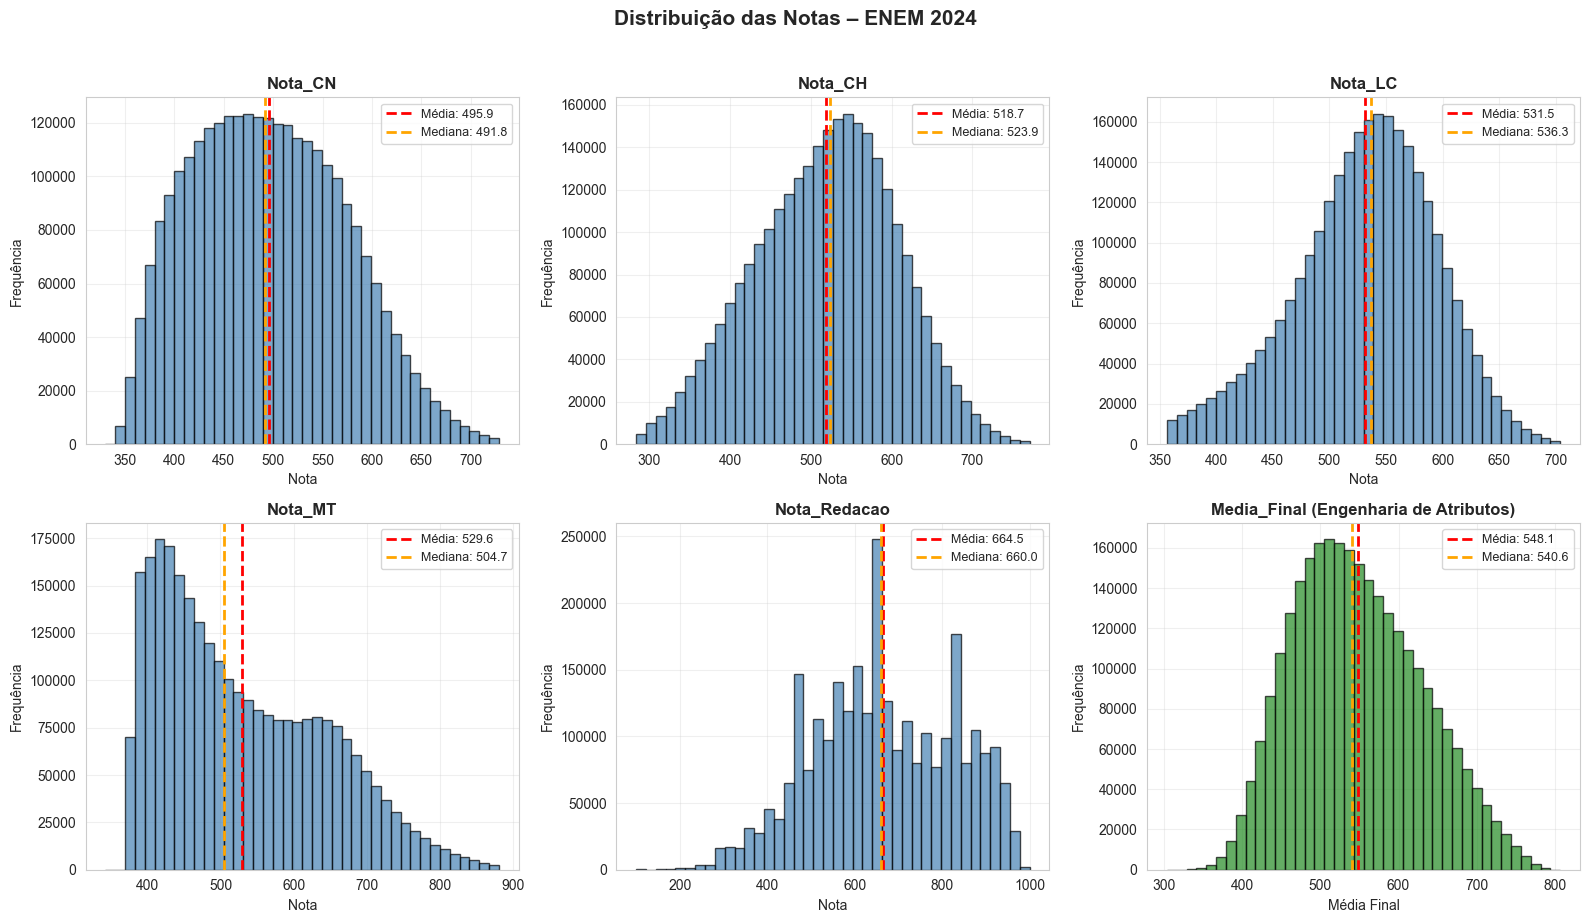

In [33]:
print("GRÁFICO 1: Distribuição das notas por disciplina")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, materia in enumerate(notas):
    axes[i].hist(df_limpo[materia], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df_limpo[materia].mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Média: {df_limpo[materia].mean():.1f}')
    axes[i].axvline(df_limpo[materia].median(), color='orange', linestyle='--', linewidth=2,
                    label=f'Mediana: {df_limpo[materia].median():.1f}')
    axes[i].set_title(materia, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Histograma da Media_Final (atributo criado na engenharia)
axes[5].hist(df_limpo['Media_Final'], bins=40, color='forestgreen', edgecolor='black', alpha=0.7)
axes[5].axvline(df_limpo['Media_Final'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média: {df_limpo["Media_Final"].mean():.1f}')
axes[5].axvline(df_limpo['Media_Final'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana: {df_limpo["Media_Final"].median():.1f}')
axes[5].set_title('Media_Final (Engenharia de Atributos)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Média Final')
axes[5].set_ylabel('Frequência')
axes[5].legend(fontsize=9)
axes[5].grid(True, alpha=0.3)

plt.suptitle('Distribuição das Notas – ENEM 2024', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### GRÁFICO 2 – Boxplot comparativo das notas e médias criadas

GRÁFICO 2: Boxplot comparativo – notas e métricas derivadas


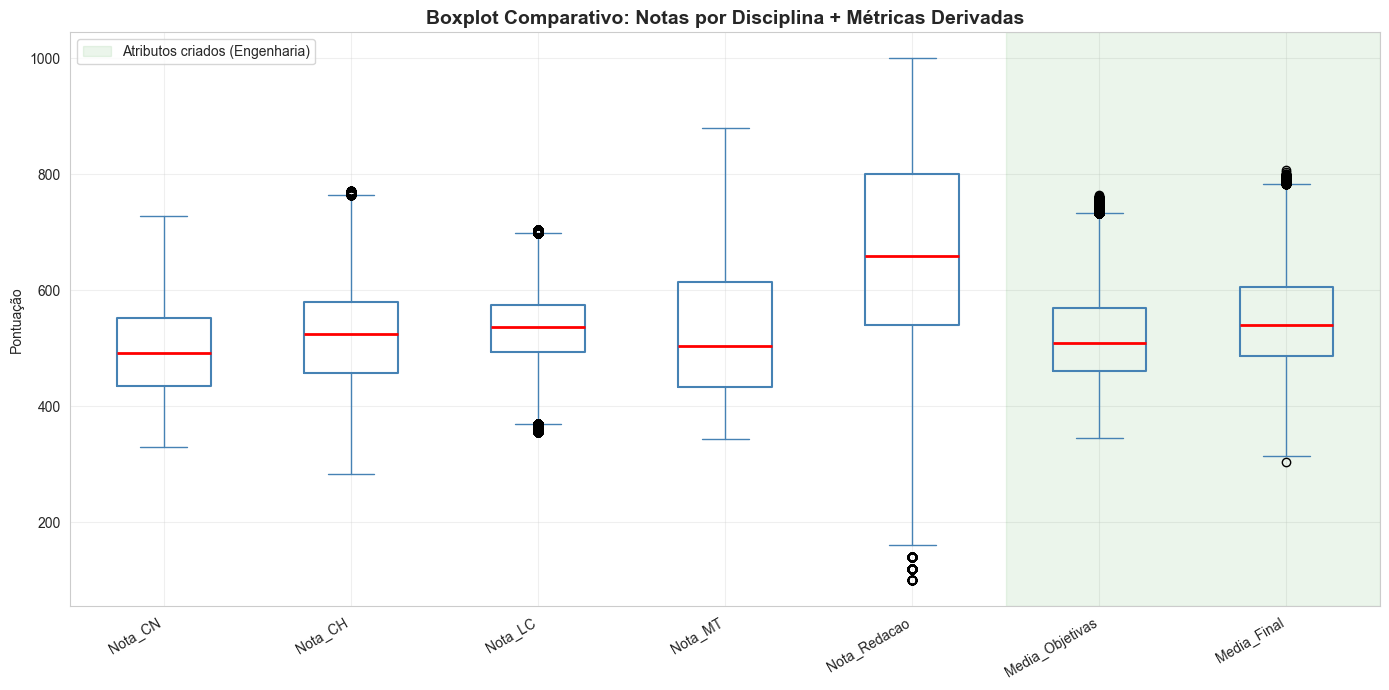

In [34]:
print("GRÁFICO 2: Boxplot comparativo – notas e métricas derivadas")

colunas_box = notas + ['Media_Objetivas', 'Media_Final']
fig, ax = plt.subplots(figsize=(14, 7))
df_limpo[colunas_box].boxplot(ax=ax, grid=True,
    boxprops=dict(color='steelblue', linewidth=1.5),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'))
ax.set_title('Boxplot Comparativo: Notas por Disciplina + Métricas Derivadas', fontsize=14, fontweight='bold')
ax.set_ylabel('Pontuação')
ax.set_xticklabels(colunas_box, rotation=30, ha='right')
# Destacar colunas da engenharia de atributos com cor de fundo
ax.axvspan(5.5, 7.5, alpha=0.08, color='green', label='Atributos criados (Engenharia)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### GRÁFICO 3 – Matriz de correlação (notas + métricas derivadas)

GRÁFICO 3: Matriz de correlação – notas e métricas derivadas


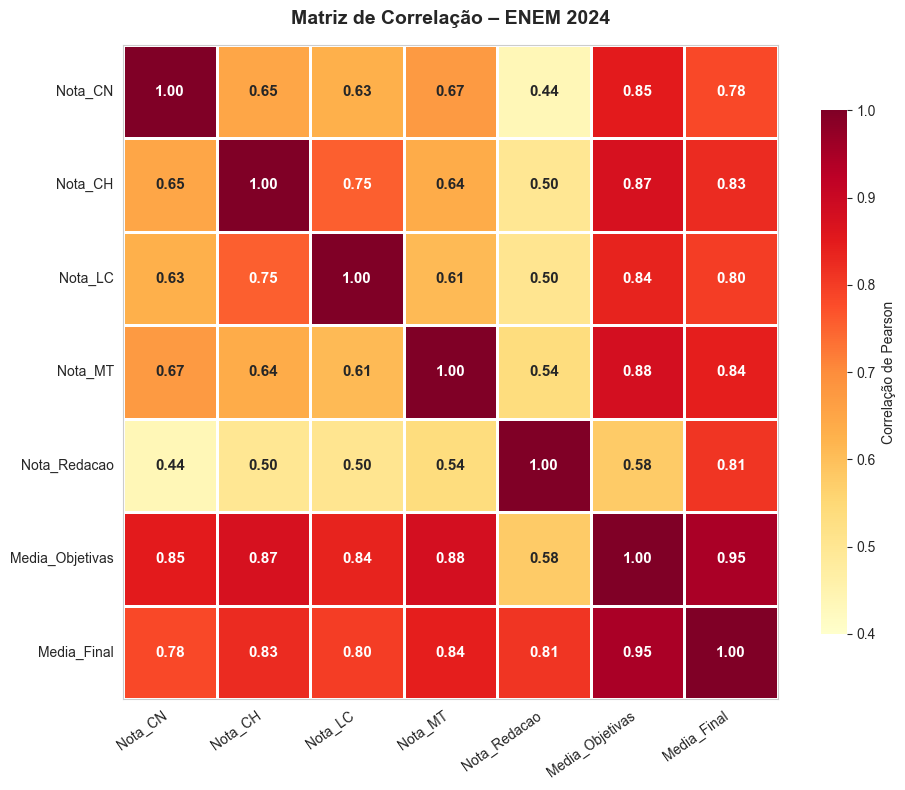


Correlações mais relevantes (|r| > 0.5):
  Media_Objetivas × Media_Final: r = 0.946
  Nota_MT × Media_Objetivas: r = 0.881
  Nota_CH × Media_Objetivas: r = 0.874
  Nota_CN × Media_Objetivas: r = 0.849
  Nota_MT × Media_Final: r = 0.844
  Nota_LC × Media_Objetivas: r = 0.837
  Nota_CH × Media_Final: r = 0.825
  Nota_Redacao × Media_Final: r = 0.810
  Nota_LC × Media_Final: r = 0.801
  Nota_CN × Media_Final: r = 0.782
  Nota_CH × Nota_LC: r = 0.755
  Nota_CN × Nota_MT: r = 0.674
  Nota_CN × Nota_CH: r = 0.649
  Nota_CH × Nota_MT: r = 0.637
  Nota_CN × Nota_LC: r = 0.628
  Nota_LC × Nota_MT: r = 0.611
  Nota_Redacao × Media_Objetivas: r = 0.577
  Nota_MT × Nota_Redacao: r = 0.536
  Nota_LC × Nota_Redacao: r = 0.505
  Nota_CH × Nota_Redacao: r = 0.500


In [35]:
print("GRÁFICO 3: Matriz de correlação – notas e métricas derivadas")

colunas_corr = notas + ['Media_Objetivas', 'Media_Final']
correlacao = df_limpo[colunas_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0.40,
    vmax=1.00,
    square=True,
    linewidths=2,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Correlação de Pearson', 'shrink': 0.8}
)

# Destacar borda das métricas derivadas
for spine in ax.spines.values():
    spine.set_visible(True)

ax.set_title('Matriz de Correlação – ENEM 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\nCorrelações mais relevantes (|r| > 0.5):")
corr_stack = correlacao.unstack()
corr_filtrada = (
    corr_stack[(corr_stack.abs() > 0.5) & (corr_stack < 0.999)]
    .drop_duplicates()
    .sort_values(ascending=False)
)
for (a, b), v in corr_filtrada.items():
    print(f"  {a} × {b}: r = {v:.3f}")

### GRÁFICO 4 – Distribuição por Nível de desempenho (atributo criado)

GRÁFICO 4: Distribuição dos alunos por Nível (criado na Engenharia de Atributos)


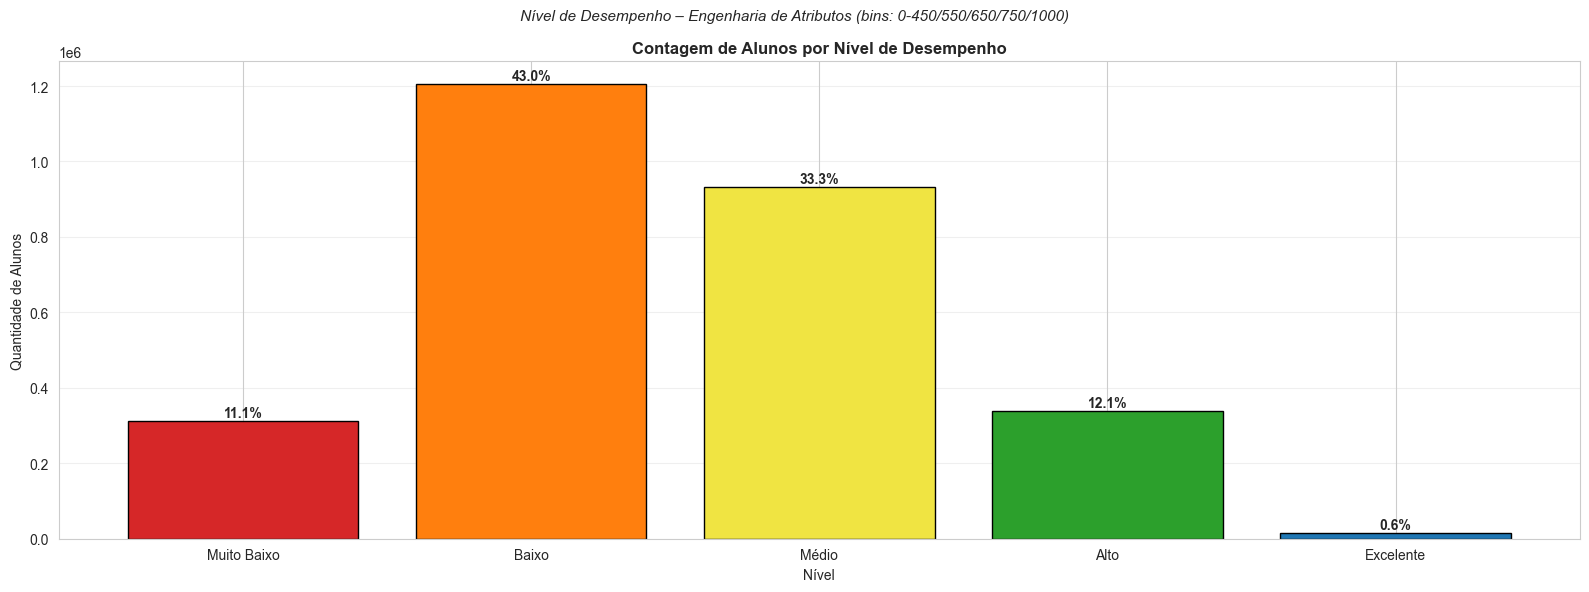


Distribuição numérica:


,Quantidade,Percentual (%)
Nivel,,
Muito Baixo,311662,11.1
Baixo,1204950,43.0
Médio,932910,33.3
Alto,337941,12.1
Excelente,16019,0.6


In [36]:
print("GRÁFICO 4: Distribuição dos alunos por Nível (criado na Engenharia de Atributos)")

ordem_nivel = ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Excelente']
cores_nivel = ['#d62728', '#ff7f0e', '#f0e442', '#2ca02c', '#1f77b4']

niveis_count = df_limpo['Nivel'].value_counts().reindex(ordem_nivel)
niveis_pct   = (niveis_count / niveis_count.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(16, 6))

# Barras
bars = ax.bar(niveis_count.index, niveis_count.values, color=cores_nivel, edgecolor='black')
for bar, pct in zip(bars, niveis_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Contagem de Alunos por Nível de Desempenho', fontsize=12, fontweight='bold')
ax.set_xlabel('Nível')
ax.set_ylabel('Quantidade de Alunos')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Nível de Desempenho – Engenharia de Atributos (bins: 0-450/550/650/750/1000)',
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()

print("\nDistribuição numérica:")
display(pd.DataFrame({'Quantidade': niveis_count, 'Percentual (%)': niveis_pct}))

In [37]:
print("\n Distribuição dos alunos por região:\n")
distribuicao = df_limpo['Regiao'].value_counts()
for regiao, qtd in distribuicao.items():
    print(f"   {regiao}: {qtd:,.0f} alunos ({qtd/len(df_limpo)*100:.1f}%)")


 Distribuição dos alunos por região:

   Nordeste: 1,016,772 alunos (36.3%)
   Sudeste: 955,102 alunos (34.1%)
   Sul: 319,348 alunos (11.4%)
   Norte: 293,332 alunos (10.5%)
   Centro-Oeste: 218,928 alunos (7.8%)



📊 GRÁFICO 5: Distribuição dos participantes


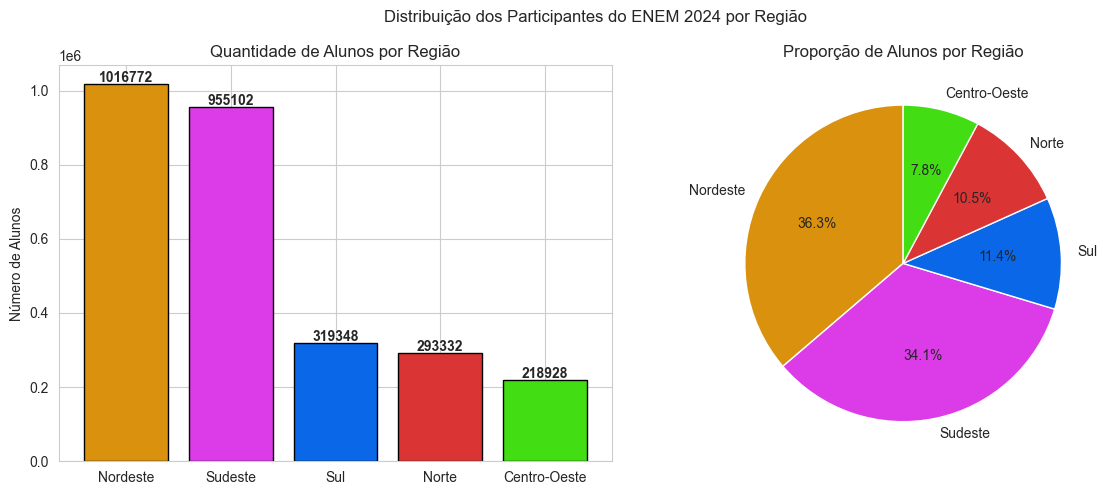

In [38]:
print("\n📊 GRÁFICO 5: Distribuição dos participantes")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
cores_regioes = {'Norte': "#db3434", 'Nordeste': "#da920e", 'Centro-Oeste': "#42dd13", 
                  'Sudeste': "#dc3ce7", 'Sul': "#0a67e8"}
colors = [cores_regioes[r] for r in distribuicao.index]

axes[0].bar(distribuicao.index, distribuicao.values, color=colors, edgecolor='black')
axes[0].set_title('Quantidade de Alunos por Região')
axes[0].set_ylabel('Número de Alunos')
axes[0].tick_params(axis='x', rotation=0)

for i, (regiao, qtd) in enumerate(distribuicao.items()):
    axes[0].text(i, qtd + 5000, f'{qtd:.0f}', ha='center', fontweight='bold')

# Pizza
axes[1].pie(distribuicao.values, labels=distribuicao.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Proporção de Alunos por Região')

plt.suptitle('Distribuição dos Participantes do ENEM 2024 por Região', fontsize=12)
plt.tight_layout()
plt.show()

### GRÁFICO 6 – Desempenho médio por Região (atributo criado)

GRÁFICO 6: Média das notas por Região (criado na Engenharia de Atributos)

Médias por região:


,Nota_CN,Nota_CH,Nota_LC,Nota_MT,Nota_Redacao,Media_Objetivas,Media_Final
Regiao,,,,,,,
Norte,474.97,492.81,509.45,490.66,632.71,491.97,520.12
Nordeste,481.87,502.80,518.74,513.39,661.30,504.20,535.62
Centro-Oeste,500.16,521.53,533.47,531.43,670.01,521.65,551.32
Sudeste,511.80,537.88,546.84,554.12,678.87,537.66,565.90
Sul,509.34,534.20,545.45,542.47,656.91,532.87,557.68


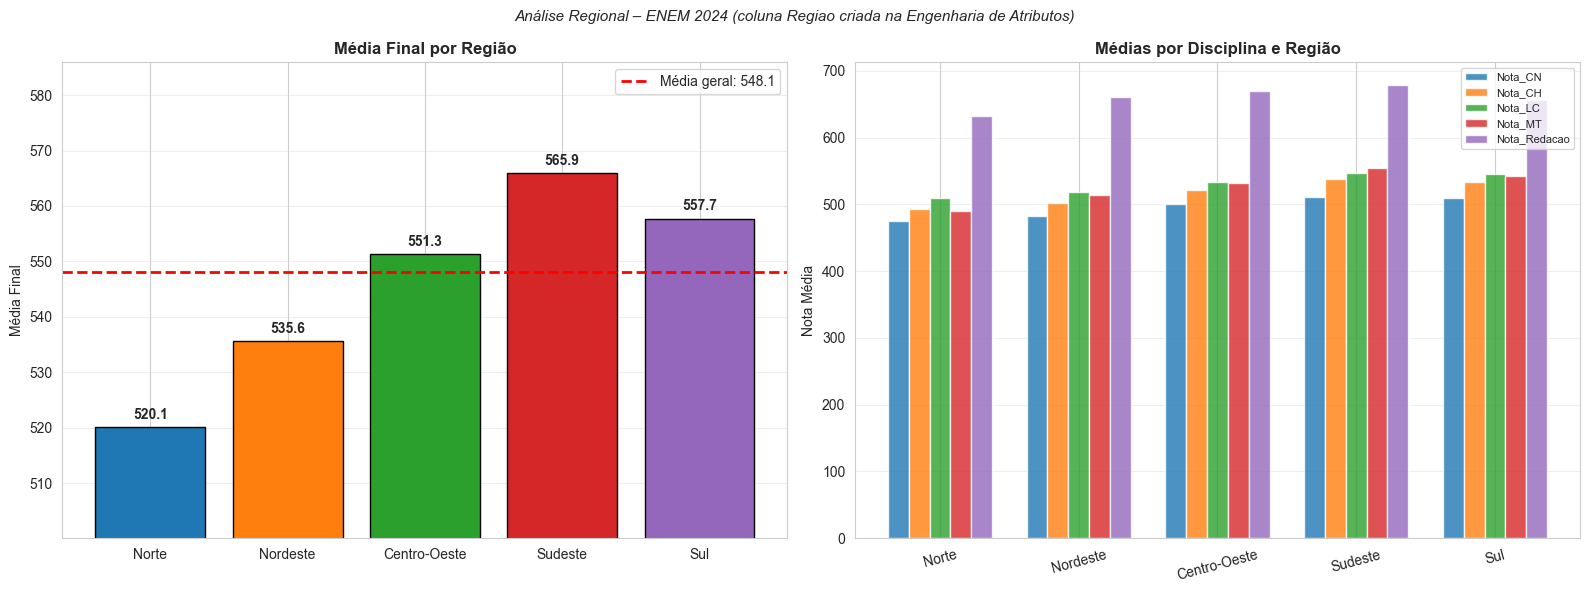

In [39]:
print("GRÁFICO 6: Média das notas por Região (criado na Engenharia de Atributos)")

ordem_regiao = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

medias_regiao = df_limpo.groupby('Regiao')[notas + ['Media_Objetivas', 'Media_Final']].mean().round(2)
medias_regiao = medias_regiao.reindex(ordem_regiao)

print("\nMédias por região:")
display(medias_regiao)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Media Final por Região
cores_r = [cores_regiao[r] for r in ordem_regiao]
bars = axes[0].bar(medias_regiao.index, medias_regiao['Media_Final'], color=cores_r, edgecolor='black')
axes[0].axhline(df_limpo['Media_Final'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média geral: {df_limpo["Media_Final"].mean():.1f}')
for bar, val in zip(bars, medias_regiao['Media_Final']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Média Final por Região', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Média Final')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(medias_regiao['Media_Final'].min() - 20, medias_regiao['Media_Final'].max() + 20)

# Todas as notas por Região (grouped bar)
x = np.arange(len(ordem_regiao))
width = 0.15
for idx, nota in enumerate(notas):
    axes[1].bar(x + idx*width, medias_regiao[nota], width, label=nota, alpha=0.8)
axes[1].set_title('Médias por Disciplina e Região', fontsize=12, fontweight='bold')
axes[1].set_xticks(x + width*2)
axes[1].set_xticklabels(ordem_regiao, rotation=15)
axes[1].set_ylabel('Nota Média')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Análise Regional – ENEM 2024 (coluna Regiao criada na Engenharia de Atributos)',
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()

### GRÁFICO 7 – Distribuição de alunos por Região e Nível (cruzamento dos atributos criados)

GRÁFICO 7: Cruzamento Região × Nível (ambos criados na Engenharia de Atributos)


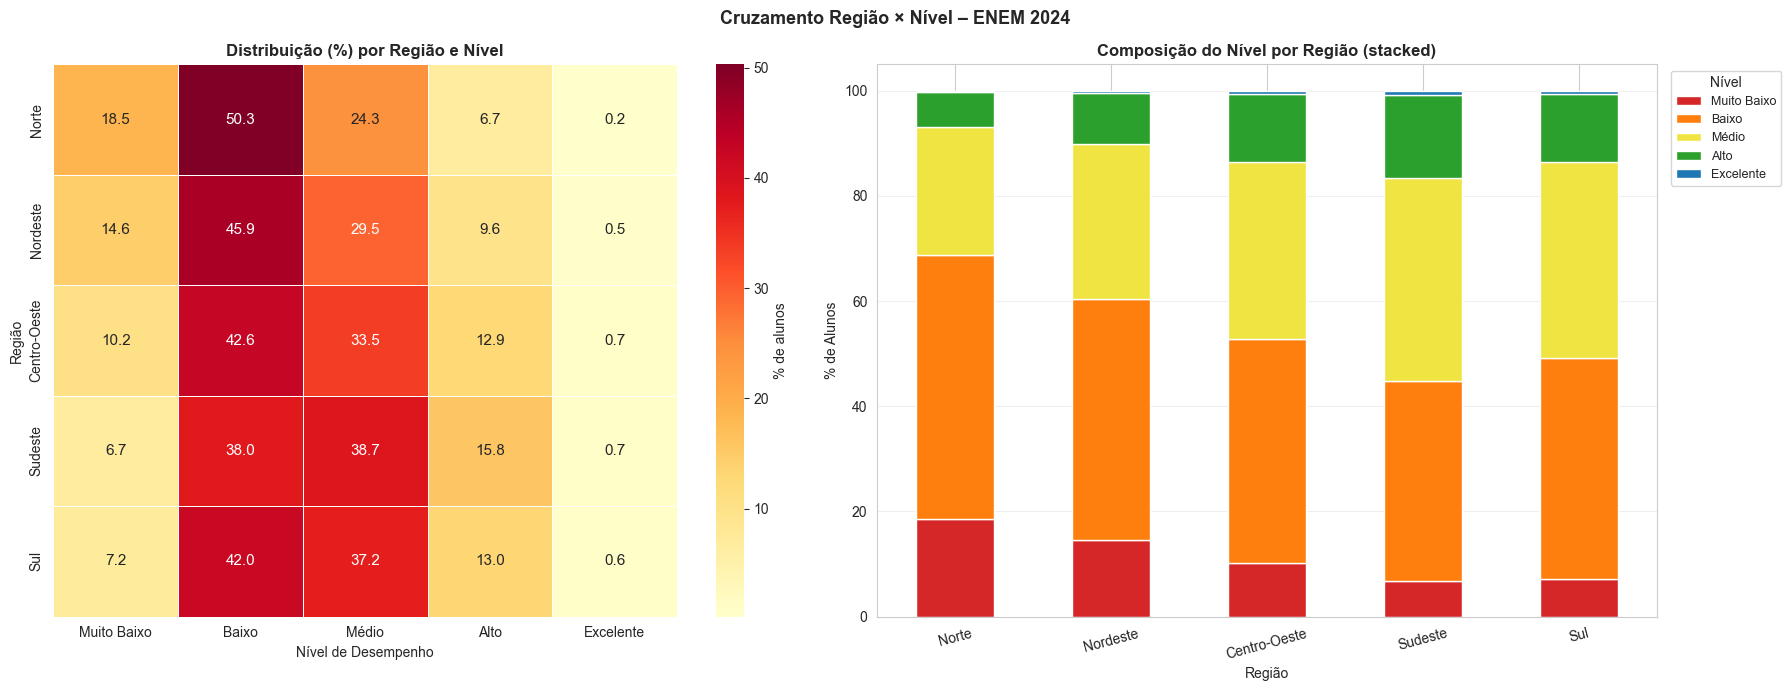

In [40]:
print("GRÁFICO 7: Cruzamento Região × Nível (ambos criados na Engenharia de Atributos)")

pivot_regiao_nivel = pd.crosstab(
    df_limpo['Regiao'],
    df_limpo['Nivel'],
    normalize='index'
)[ordem_nivel].reindex(ordem_regiao) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(pivot_regiao_nivel.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '% de alunos'},
            annot_kws={'size': 11})
axes[0].set_title('Distribuição (%) por Região e Nível', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nível de Desempenho')
axes[0].set_ylabel('Região')

# Stacked bar
pivot_regiao_nivel.plot(kind='bar', stacked=True, ax=axes[1],
                         color=cores_nivel, edgecolor='white')
axes[1].set_title('Composição do Nível por Região (stacked)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('% de Alunos')
axes[1].set_xticklabels(ordem_regiao, rotation=15)
axes[1].legend(title='Nível', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Cruzamento Região × Nível – ENEM 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### GRÁFICO 8 – Boxplot da Media_Final por Região

GRÁFICO 8: Boxplot da Media_Final por Região


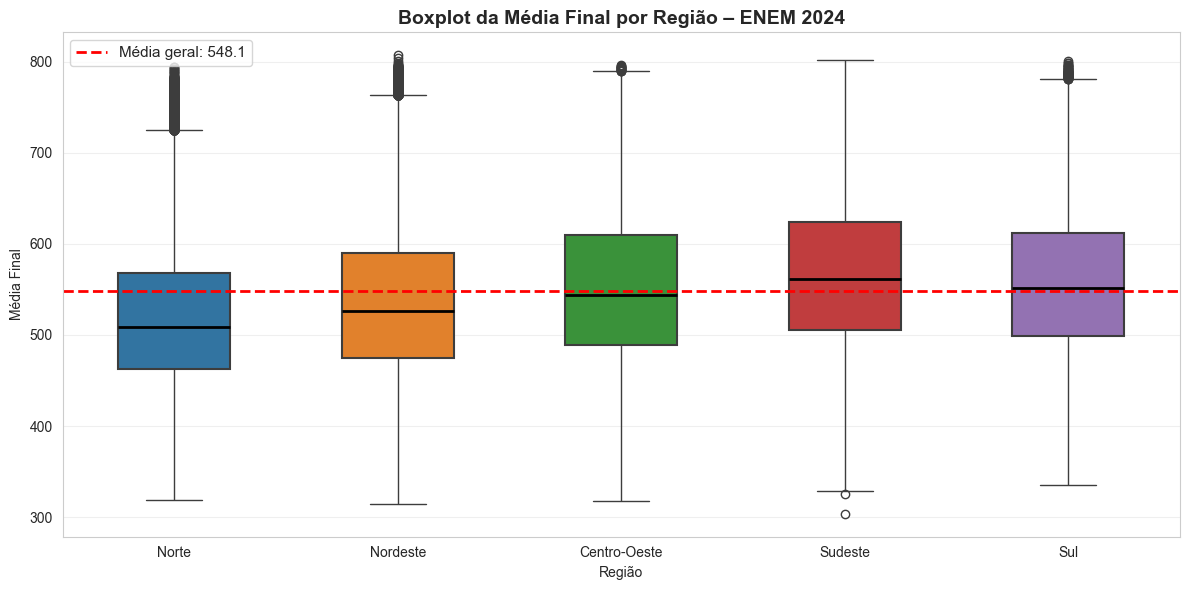

In [41]:
print("GRÁFICO 8: Boxplot da Media_Final por Região")

df_plot = df_limpo[df_limpo['Regiao'].isin(ordem_regiao)].copy()
df_plot['Regiao'] = pd.Categorical(df_plot['Regiao'], categories=ordem_regiao, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Regiao', y='Media_Final', order=ordem_regiao,
            palette=cores_regiao, ax=ax, width=0.5,
            boxprops=dict(linewidth=1.5),
            medianprops=dict(color='black', linewidth=2))
ax.axhline(df_limpo['Media_Final'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Média geral: {df_limpo["Media_Final"].mean():.1f}')
ax.set_title('Boxplot da Média Final por Região – ENEM 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Região')
ax.set_ylabel('Média Final')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### GRÁFICO 9 – Idioma estrangeiro × desempenho (Media_Final e Media_Objetivas)

GRÁFICO 9: Desempenho por Língua Estrangeira escolhida

Médias por língua estrangeira:


,Media_Objetivas,Media_Final,Nota_LC
Lingua_Estrangeira,,,
Espanhol,490.42,517.22,509.73
Ingles,538.55,569.24,546.52



Quantidade de alunos por língua:


Lingua_Estrangeira
Ingles      1661692
Espanhol    1141790
Name: count, dtype: int64

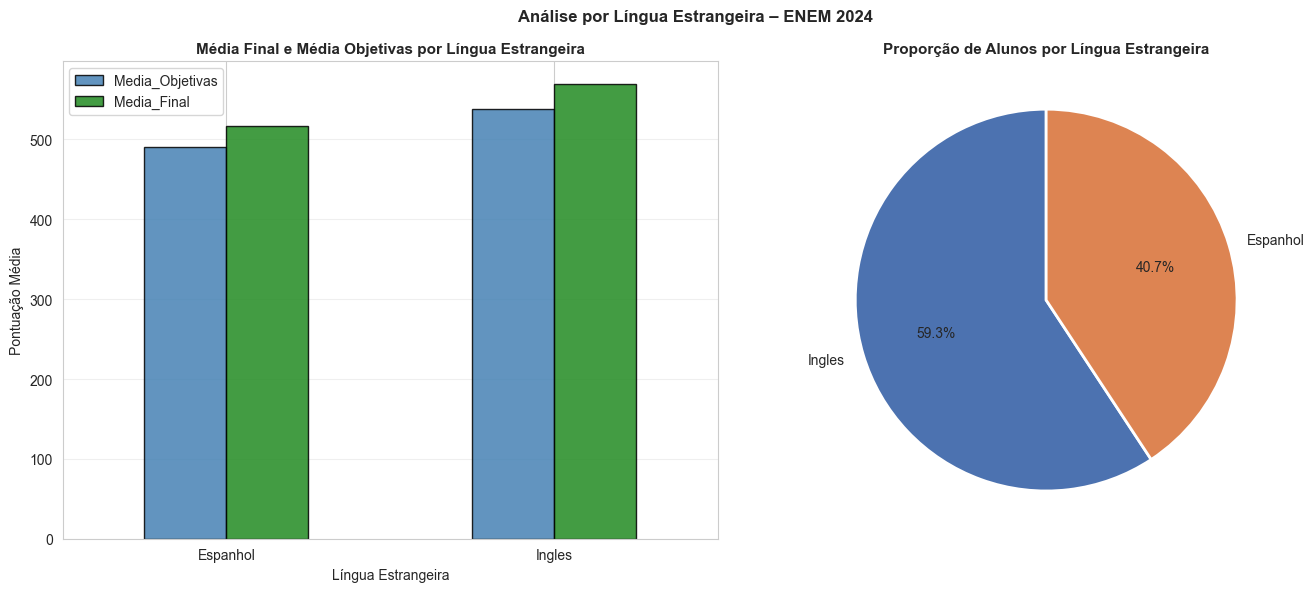

In [42]:
print("GRÁFICO 9: Desempenho por Língua Estrangeira escolhida")

lingua_media = df_limpo.groupby('Lingua_Estrangeira')[['Media_Objetivas', 'Media_Final', 'Nota_LC']].mean().round(2)
lingua_count = df_limpo['Lingua_Estrangeira'].value_counts()

print("\nMédias por língua estrangeira:")
display(lingua_media)
print("\nQuantidade de alunos por língua:")
display(lingua_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras: Media_Final e Media_Objetivas
lingua_media[['Media_Objetivas', 'Media_Final']].plot(kind='bar', ax=axes[0],
    color=['steelblue', 'forestgreen'], edgecolor='black', alpha=0.85)
axes[0].set_title('Média Final e Média Objetivas por Língua Estrangeira', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Língua Estrangeira')
axes[0].set_ylabel('Pontuação Média')
axes[0].set_xticklabels(lingua_media.index, rotation=0)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Pizza: distribuição
axes[1].pie(lingua_count.values, labels=lingua_count.index, autopct='%1.1f%%',
            colors=['#4c72b0', '#dd8452'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção de Alunos por Língua Estrangeira', fontsize=11, fontweight='bold')

plt.suptitle('Análise por Língua Estrangeira – ENEM 2024', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### GRÁFICO 10 – Scatter: Media_Objetivas × Nota_Redacao (colorido por Nível)

GRÁFICO 10: Relação entre Média das Objetivas e Nota Redação, por Nível


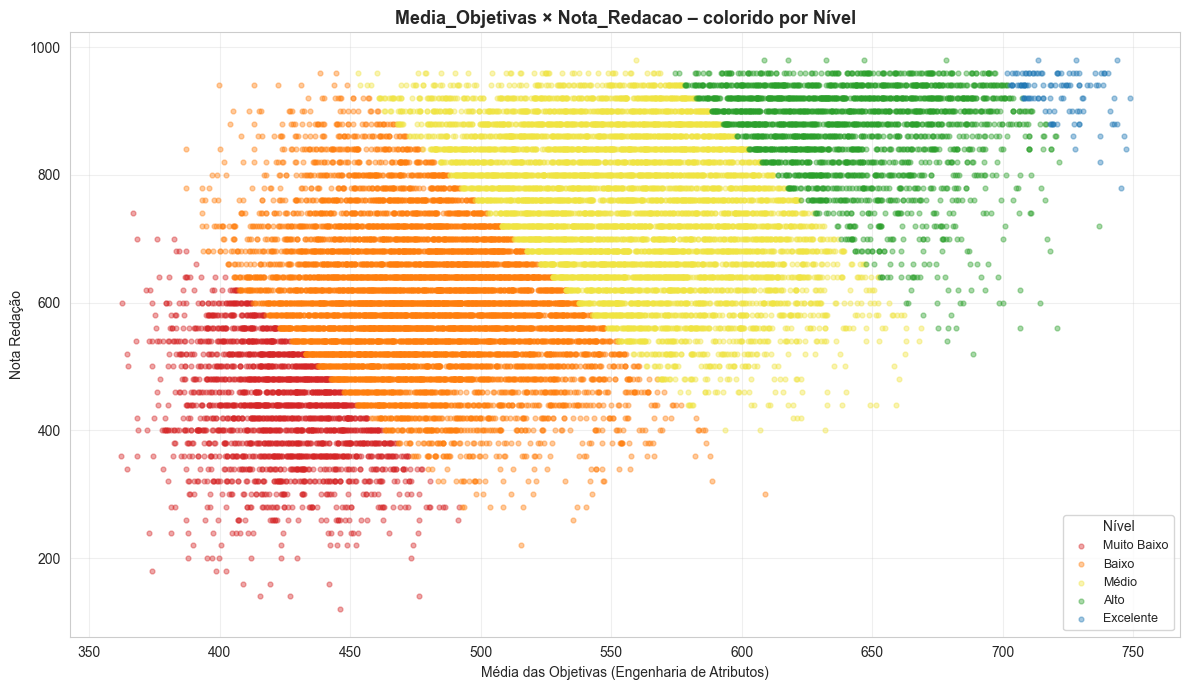


Correlação Media_Objetivas × Nota_Redacao: r = 0.577


In [43]:
print("GRÁFICO 10: Relação entre Média das Objetivas e Nota Redação, por Nível")

# Amostra para performance
amostra = df_limpo.sample(min(20000, len(df_limpo)), random_state=42)

mapa_cor_nivel = {
    'Muito Baixo': '#d62728', 'Baixo': '#ff7f0e',
    'Médio': '#f0e442', 'Alto': '#2ca02c', 'Excelente': '#1f77b4'
}

fig, ax = plt.subplots(figsize=(12, 7))
for nivel in ordem_nivel:
    sub = amostra[amostra['Nivel'] == nivel]
    ax.scatter(sub['Media_Objetivas'], sub['Nota_Redacao'],
               c=mapa_cor_nivel[nivel], label=nivel, alpha=0.4, s=12)

ax.set_title('Media_Objetivas × Nota_Redacao – colorido por Nível', fontsize=13, fontweight='bold')
ax.set_xlabel('Média das Objetivas (Engenharia de Atributos)')
ax.set_ylabel('Nota Redação')
ax.legend(title='Nível', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_obj_red = df_limpo['Media_Objetivas'].corr(df_limpo['Nota_Redacao'])
print(f"\nCorrelação Media_Objetivas × Nota_Redacao: r = {corr_obj_red:.3f}")

### Principais insights

In [44]:

print("PRINCIPAIS INSIGHTS – EDA ENEM 2024")

notas_medias = df_limpo[notas].mean()
print(f"\n[Desempenho geral]")
print(f"  Melhor disciplina : {notas_medias.idxmax()} ({notas_medias.max():.1f} pts)")
print(f"  Pior disciplina   : {notas_medias.idxmin()} ({notas_medias.min():.1f} pts)")
print(f"  Média geral (Media_Final): {df_limpo['Media_Final'].mean():.1f} pts")
print(f"  Média objetivas   : {df_limpo['Media_Objetivas'].mean():.1f} pts")

print(f"\n[Níveis de desempenho]")
for nivel in ordem_nivel:
    n = (df_limpo['Nivel'] == nivel).sum()
    print(f"  {nivel:12s}: {n:>10,} alunos ({n/len(df_limpo)*100:.1f}%)")

print(f"\n[Análise regional]")
mf_regiao = df_limpo.groupby('Regiao')['Media_Final'].mean().sort_values(ascending=False)
print(f"  Região com maior média: {mf_regiao.idxmax()} ({mf_regiao.max():.1f} pts)")
print(f"  Região com menor média: {mf_regiao.idxmin()} ({mf_regiao.min():.1f} pts)")
print(f"  Diferença entre extremos: {mf_regiao.max() - mf_regiao.min():.1f} pts")

print(f"\n[Correlações mais fortes]")
corr_full = df_limpo[notas + ['Media_Objetivas', 'Media_Final']].corr().unstack()
corr_top = corr_full[(corr_full.abs() > 0.5) & (corr_full < 0.999)].drop_duplicates().sort_values(ascending=False)
for (a, b), v in corr_top.head(5).items():
    print(f"  {a} × {b}: r = {v:.3f}")



PRINCIPAIS INSIGHTS – EDA ENEM 2024

[Desempenho geral]
  Melhor disciplina : Nota_Redacao (664.5 pts)
  Pior disciplina   : Nota_CN (495.9 pts)
  Média geral (Media_Final): 548.1 pts
  Média objetivas   : 518.9 pts

[Níveis de desempenho]
  Muito Baixo :    311,662 alunos (11.1%)
  Baixo       :  1,204,950 alunos (43.0%)
  Médio       :    932,910 alunos (33.3%)
  Alto        :    337,941 alunos (12.1%)
  Excelente   :     16,019 alunos (0.6%)

[Análise regional]
  Região com maior média: Sudeste (565.9 pts)
  Região com menor média: Norte (520.1 pts)
  Diferença entre extremos: 45.8 pts

[Correlações mais fortes]
  Media_Objetivas × Media_Final: r = 0.946
  Nota_MT × Media_Objetivas: r = 0.881
  Nota_CH × Media_Objetivas: r = 0.874
  Nota_CN × Media_Objetivas: r = 0.849
  Nota_MT × Media_Final: r = 0.844


### Exportação do dataset final

In [47]:
import os

caminho = '../Dados/dataset_limpo.csv'

if not os.path.exists(caminho):
    df_limpo.to_csv(caminho, index=False, encoding='utf-8-sig')
    print("Dataset exportado! Arquivo: Dados/dataset_limpo.csv")
    display(df_limpo.head())
else:
    print("Arquivo já existe! Exportação ignorada.")

Arquivo já existe! Exportação ignorada.
